# NB02 — Environment Exploration (Apple Full-Body)

Deep-dive into `UnitreeG1PlaceAppleInBowlFullBody-v1`: observation space,
action groups, balance dynamics, reward structure, and reset distribution.
This builds intuition before training in NB05–NB07.

**Robot:** Unitree G1 Full Body (37 DOF, free-floating root)
**Task:** Pick up apple → place in bowl → release — while staying balanced


## Objectives

1. Map every observation dimension to its meaning.
2. Map action dimensions to body-part groups (legs, torso, arms, hands).
3. Analyse balance: how quickly does the robot fall with random actions?
4. Analyse per-step reward distribution (random policy).
5. Visualise reset distribution (apple/bowl positions across seeds).
6. Compare complexity vs single-arm Panda (7 DOF).


## Resources

| Resource | Requirement | Notes |
|----------|-------------|-------|
| GPU | Not required | CPU OK |
| RAM | 4 GB | |
| Runtime | ~5-10 min | |


## Imports & Setup


In [18]:
import sys, os, json, random
from pathlib import Path

# --- 1. ค้นหา Project Root (ต้องทำก่อน เพราะต้องใช้โหลด .env.local) ---
try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    _cwd = Path.cwd()
    PROJECT_ROOT = _cwd
    for _candidate in [_cwd, _cwd.parent, _cwd.parent.parent]:
        if (_candidate / "src").is_dir():
            PROJECT_ROOT = _candidate
            break

sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

# --- 2. โหลด .env.local (VK_ICD_FILENAMES, MLFLOW creds ฯลฯ) ---
try:
    from dotenv import load_dotenv
    _env_file = PROJECT_ROOT / ".env.local"
    if _env_file.exists():
        load_dotenv(_env_file, override=False)   # ไม่ทับค่าที่ set ไว้แล้ว
        print(f"✅ Loaded {_env_file.name}")
    else:
        print(f"⚠️  .env.local not found — run scripts/runpod_setup.sh to generate it")
except ImportError:
    print("⚠️  python-dotenv not installed — using defaults")

# --- 3. Vulkan fallback defaults (ถ้า .env.local ไม่ได้ set ไว้) ---
os.environ.setdefault("VK_ICD_FILENAMES", "/usr/share/vulkan/icd.d/lvp_icd.json")
os.environ.setdefault("MESA_VK_DEVICE_SELECT", "10005:0")

import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt

import mani_skill.envs
from mani_skill.utils.wrappers.gymnasium import CPUGymWrapper

# --- 4. Dynamic Import ---
ENV_MODULE_PATHS = [
    PROJECT_ROOT / "apple_fullbody_env.py",
    PROJECT_ROOT / "src" / "envs" / "apple_fullbody_env.py",
    Path.cwd() / "apple_fullbody_env.py",
]

def _dynamic_import_from_path(py_path: Path, module_name: str):
    import importlib.util
    spec = importlib.util.spec_from_file_location(module_name, str(py_path))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

env_mod = None
_import_err = None
try:
    import src.envs as _src_envs
    env_mod = _src_envs
except Exception as e:
    _import_err = e
    for p in ENV_MODULE_PATHS:
        if p.exists():
            try:
                env_mod = _dynamic_import_from_path(p, "apple_fullbody_env")
                break
            except Exception as e2:
                print(f"⚠️  Fallback import {p} failed: {e2}")

assert env_mod is not None, (
    f"❌ Cannot import apple_fullbody env module.\n"
    f"PROJECT_ROOT={PROJECT_ROOT}\nLast error: {_import_err}"
)
print("✅ Env module loaded and registered successfully!")

# --- 5. สร้าง Artifacts Directory ---
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "NB02"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


PROJECT_ROOT: /root/robotic-sim-dishwash
✅ Loaded .env.local
✅ Env module loaded and registered successfully!


## Configuration


In [4]:
CFG = {
    "seed":               42,
    "env_id":             "UnitreeG1PlaceAppleInBowlFullBody-v1",
    "control_mode":       "pd_joint_delta_pos",
    "n_explore_episodes": 10,
    "n_explore_steps":    200,
    "n_seeds_reset":      6,
}

SEED = CFG["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Config loaded, seeds set")


Config loaded, seeds set


## Create Environment


In [8]:
def _make_env(render_mode="rgb_array", render_backend="cpu"):
    e = gym.make(
        CFG["env_id"],
        num_envs=1,
        obs_mode="state",
        control_mode=CFG["control_mode"],
        render_mode=render_mode,
        render_backend=render_backend,
    )
    return CPUGymWrapper(e)

RENDER_AVAILABLE = True
try:
    env = _make_env(render_mode="rgb_array", render_backend="cpu")
except RuntimeError as _e:
    print(f"⚠️  Vulkan unavailable ({_e.__class__.__name__}: {_e})")
    print("   Falling back to render_backend='none' — Step 7 renders will be skipped.")
    RENDER_AVAILABLE = False
    env = _make_env(render_mode=None, render_backend="none")

obs, info = env.reset(seed=SEED)
print(f"Env created: obs={obs.shape}, act={env.action_space.shape}")
print(f"Rendering available: {RENDER_AVAILABLE}")


[2026-03-03 05:52:30.624] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-03 05:52:30.652] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-03 05:52:30.659] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-03 05:52:30.671] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-03 05:52:30.708] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do yo

Env created: obs=(94,), act=(37,)
Rendering available: True


## Step 1 — Observation Breakdown

Full-body G1 observations include proprioception (joint positions &
velocities), torso orientation, and task-specific features (apple/bowl
positions, hand positions, grasp states).


Total observation dimensions: 94

Raw observation (first 20): [ 0.0385  0.0297  0.018  -0.0421  0.0136 -0.0247 -0.0009 -0.0321 -0.015
  0.233  -0.2078 -0.0281 -0.0146 -0.0112 -0.0154  0.0152  0.0328  0.8968
  0.8901  0.0088]
Raw observation (last 20):  [-0.163  -0.2357  0.6789  0.8989 -0.0915  0.4261 -0.0447  0.0205  0.0072
  0.7335  0.0104 -0.3921  0.753   0.1836  0.2429  0.0546 -0.0102 -0.3993
  0.0195  0.    ]

Active joints: 37
Expected proprioception dims: 74 (qpos + qvel)
Remaining obs dims: 20 (task features)


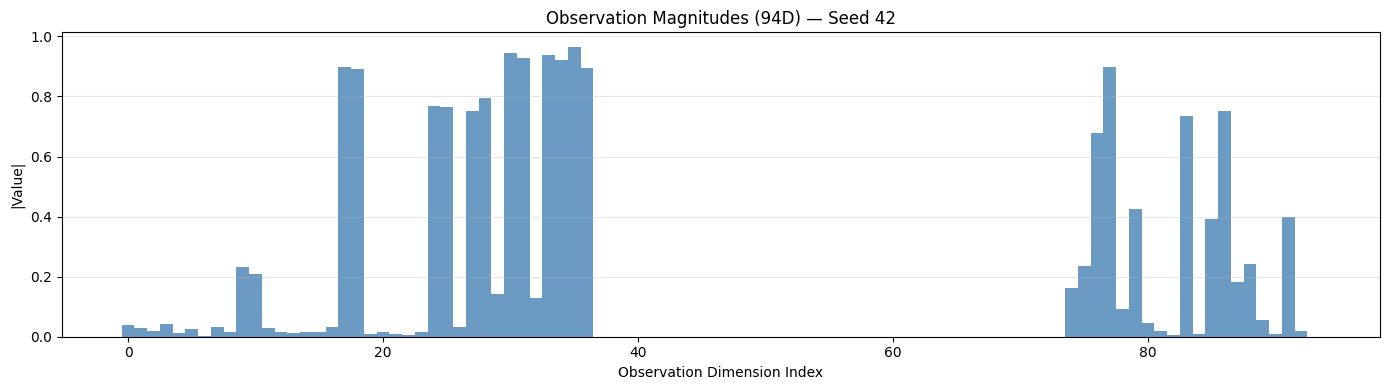

Saved: obs_breakdown.png


In [9]:
obs_total = obs.shape[0]
print(f"Total observation dimensions: {obs_total}")
print(f"\nRaw observation (first 20): {obs[:20].round(4)}")
print(f"Raw observation (last 20):  {obs[-20:].round(4)}")

# Attempt to probe observation structure from env internals
try:
    base_env = env.unwrapped
    agent = base_env.agent
    robot = agent.robot
    n_joints = len(robot.active_joints)
    print(f"\nActive joints: {n_joints}")
    print(f"Expected proprioception dims: {n_joints * 2} (qpos + qvel)")
    print(f"Remaining obs dims: {obs_total - n_joints * 2} (task features)")
except Exception as e:
    n_joints = 37
    print(f"Could not access internals: {e}")

# Structured breakdown (approximate — exact mapping depends on env)
obs_breakdown = {
    "total_dims": obs_total,
    "approximate_groups": {
        "joint_positions (qpos)": n_joints,
        "joint_velocities (qvel)": n_joints,
        "torso_orientation": "4D (quaternion)",
        "torso_angular_velocity": "3D",
        "apple_position": "3D",
        "bowl_position": "3D",
        "hand_positions": "6D (left 3 + right 3)",
        "grasp_state": "varies",
    },
}

with open(ARTIFACTS_DIR / "obs_breakdown.json", "w") as f:
    json.dump(obs_breakdown, f, indent=2, default=str)

# Visualise observation magnitudes
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(obs_total), np.abs(obs), color="steelblue", width=1.0, alpha=0.8)
ax.set_xlabel("Observation Dimension Index")
ax.set_ylabel("|Value|")
ax.set_title(f"Observation Magnitudes ({obs_total}D) — Seed {SEED}")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "obs_breakdown.png", dpi=150)
plt.show()
print("Saved: obs_breakdown.png")


## Step 2 — Action Groups by Body Part

Map each action dimension to a body part. With `pd_joint_delta_pos`
control mode, each action dim corresponds to one joint.


Action dimensions: 37

Action groups:
  left_leg: 6 joints
    [ 0] left_hip_pitch_joint
    [ 3] left_hip_roll_joint
    [ 7] left_hip_yaw_joint
    [11] left_knee_joint
    [15] left_ankle_pitch_joint
    [19] left_ankle_roll_joint
  right_leg: 6 joints
    [ 1] right_hip_pitch_joint
    [ 4] right_hip_roll_joint
    [ 8] right_hip_yaw_joint
    [12] right_knee_joint
    [16] right_ankle_pitch_joint
    [20] right_ankle_roll_joint
  torso: 1 joints
    [ 2] torso_joint
  left_arm: 5 joints
    [ 5] left_shoulder_pitch_joint
    [ 9] left_shoulder_roll_joint
    [13] left_shoulder_yaw_joint
    [17] left_elbow_pitch_joint
    [21] left_elbow_roll_joint
  right_arm: 5 joints
    [ 6] right_shoulder_pitch_joint
    [10] right_shoulder_roll_joint
    [14] right_shoulder_yaw_joint
    [18] right_elbow_pitch_joint
    [22] right_elbow_roll_joint
  left_hand: 7 joints
    [23] left_zero_joint
    [24] left_three_joint
    [25] left_five_joint
    [29] left_one_joint
    [30] left_four_joint

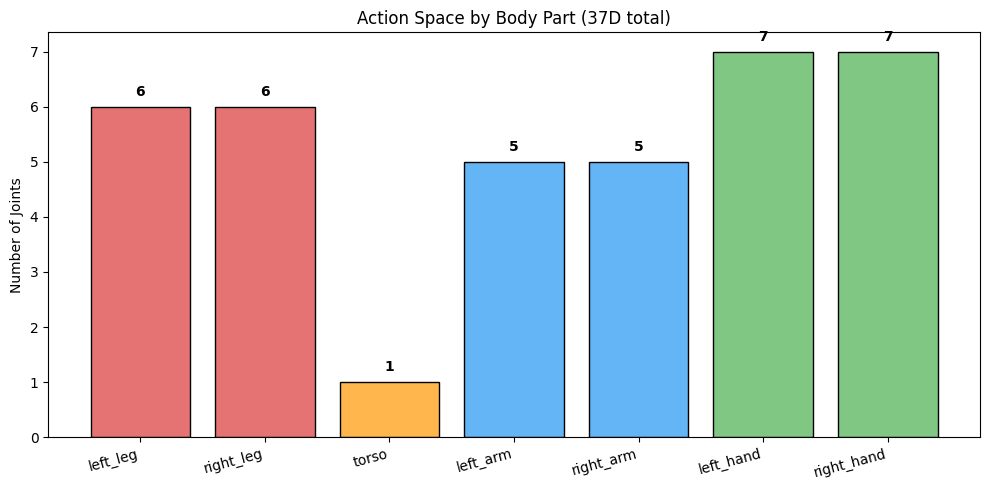

Saved: action_groups.png


In [10]:
act_dim = env.action_space.shape[0]
print(f"Action dimensions: {act_dim}")

try:
    agent = env.unwrapped.agent
    joint_names = [j.name for j in agent.robot.active_joints]

    def classify_joint(name):
        n = name.lower()
        if any(k in n for k in ["hip", "knee", "ankle"]):
            side = "left_leg" if "left" in n else "right_leg"
            return side
        if any(k in n for k in ["torso", "waist"]):
            return "torso"
        if any(k in n for k in ["shoulder", "elbow", "wrist"]):
            side = "left_arm" if "left" in n else "right_arm"
            return side
        return "left_hand" if "left" in name.lower() else "right_hand"

    action_groups = {}
    for i, jn in enumerate(joint_names):
        g = classify_joint(jn)
        action_groups.setdefault(g, []).append({"idx": i, "name": jn})

except Exception as e:
    print(f"Could not access joints: {e}")
    action_groups = {"all_joints": [{"idx": i, "name": f"joint_{i}"} for i in range(act_dim)]}

group_sizes = {k: len(v) for k, v in action_groups.items()}
print("\nAction groups:")
for g, joints in action_groups.items():
    print(f"  {g}: {len(joints)} joints")
    for j in joints:
        print(f"    [{j['idx']:2d}] {j['name']}")

with open(ARTIFACTS_DIR / "action_groups.json", "w") as f:
    json.dump({k: [j["name"] for j in v] for k, v in action_groups.items()}, f, indent=2)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
group_order = ["left_leg", "right_leg", "torso", "left_arm", "right_arm",
               "left_hand", "right_hand"]
group_order = [g for g in group_order if g in group_sizes]
colors = ["#E57373", "#E57373", "#FFB74D", "#64B5F6", "#64B5F6", "#81C784", "#81C784"]
sizes_ordered = [group_sizes[g] for g in group_order]
bars = ax.bar(group_order, sizes_ordered, color=colors[:len(group_order)], edgecolor="black")
for b, v in zip(bars, sizes_ordered):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2, str(v),
            ha="center", fontweight="bold")
ax.set_ylabel("Number of Joints")
ax.set_title(f"Action Space by Body Part ({act_dim}D total)")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha="right")
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "action_groups.png", dpi=150)
plt.show()
print("Saved: action_groups.png")


## Step 3 — Balance Analysis

How quickly does the robot fall with a random policy?
This quantifies the challenge of maintaining balance while manipulating.


Balance Analysis (Random Policy):
  mean_steps_to_end: 200.0
  min_steps_to_end: 200
  max_steps_to_end: 200
  std_steps_to_end: 0.0
  survived_full_ep: 10
  n_episodes: 10


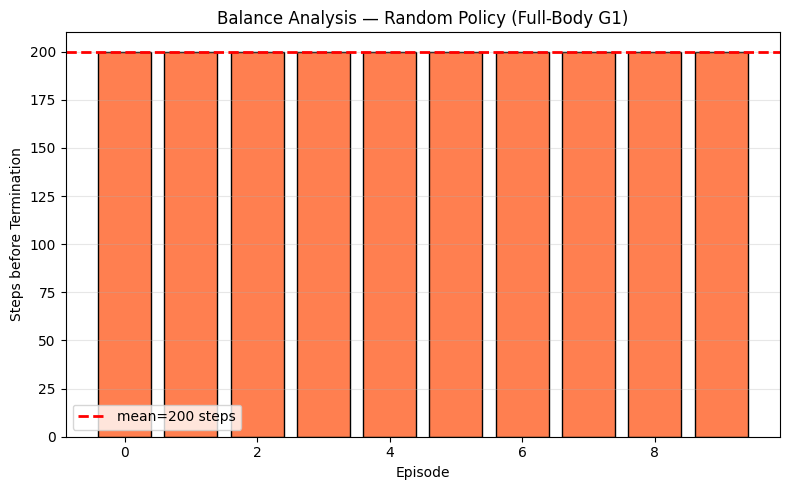

Saved: balance_analysis.png


In [11]:
fall_steps = []
for ep in range(CFG["n_explore_episodes"]):
    obs, info = env.reset(seed=ep * 42)
    for step in range(CFG["n_explore_steps"]):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            fall_steps.append(step + 1)
            break
    else:
        fall_steps.append(CFG["n_explore_steps"])

balance_stats = {
    "mean_steps_to_end": float(np.mean(fall_steps)),
    "min_steps_to_end":  int(np.min(fall_steps)),
    "max_steps_to_end":  int(np.max(fall_steps)),
    "std_steps_to_end":  float(np.std(fall_steps)),
    "survived_full_ep":  int(sum(s == CFG["n_explore_steps"] for s in fall_steps)),
    "n_episodes":        len(fall_steps),
}

print("Balance Analysis (Random Policy):")
for k, v in balance_stats.items():
    print(f"  {k}: {v}")

with open(ARTIFACTS_DIR / "balance_analysis.json", "w") as f:
    json.dump(balance_stats, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(fall_steps)), fall_steps, color="coral", edgecolor="black")
ax.axhline(np.mean(fall_steps), color="red", ls="--", lw=2,
           label=f"mean={np.mean(fall_steps):.0f} steps")
ax.set_xlabel("Episode")
ax.set_ylabel("Steps before Termination")
ax.set_title("Balance Analysis — Random Policy (Full-Body G1)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "balance_analysis.png", dpi=150)
plt.show()
print("Saved: balance_analysis.png")


## Step 4 — Reward Structure Analysis

Collect per-step rewards with random actions to understand the reward
distribution. The Apple env uses 4-stage dense reward (reaching →
grasping → placing → releasing), max normalized ~10.


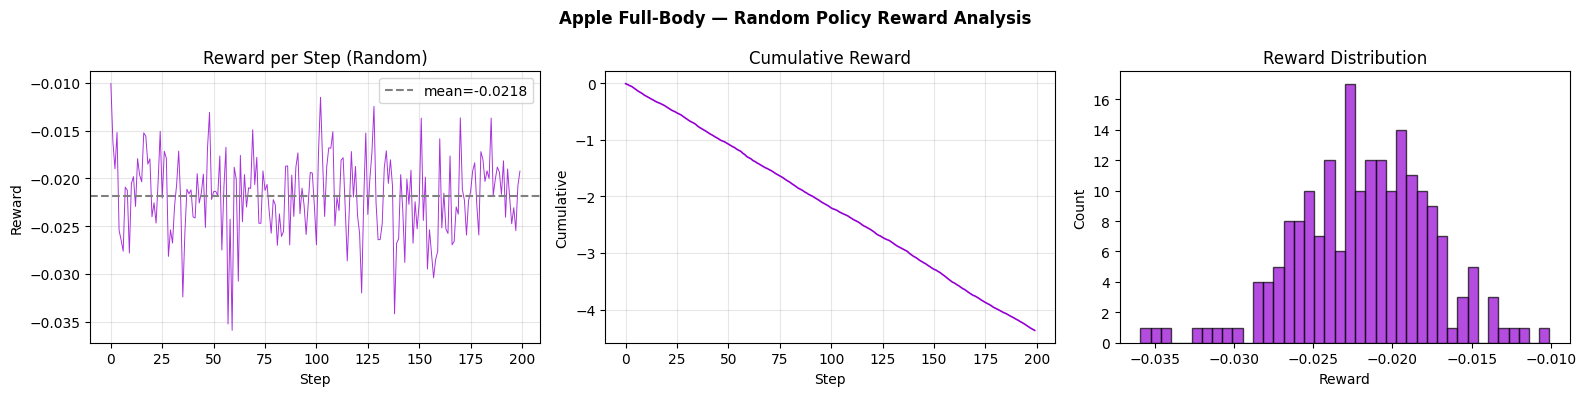

Reward stats: mean=-0.0218, std=0.0043
  min=-0.0359, max=-0.0101
  nonzero: 100.0%


In [12]:
obs, info = env.reset(seed=SEED)
rewards = []
for step in range(200):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(float(reward))
    if terminated or truncated:
        obs, info = env.reset()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(rewards, linewidth=0.7, color="darkviolet", alpha=0.8)
axes[0].axhline(np.mean(rewards), color="gray", ls="--",
                label=f"mean={np.mean(rewards):.4f}")
axes[0].set_title("Reward per Step (Random)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.cumsum(rewards), linewidth=1.2, color="darkviolet")
axes[1].set_title("Cumulative Reward")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Cumulative")
axes[1].grid(True, alpha=0.3)

axes[2].hist(rewards, bins=40, color="darkviolet", edgecolor="black", alpha=0.7)
axes[2].set_title("Reward Distribution")
axes[2].set_xlabel("Reward")
axes[2].set_ylabel("Count")

fig.suptitle("Apple Full-Body — Random Policy Reward Analysis", fontweight="bold")
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "reward_per_step.png", dpi=150)
plt.show()

print(f"Reward stats: mean={np.mean(rewards):.4f}, std={np.std(rewards):.4f}")
print(f"  min={np.min(rewards):.4f}, max={np.max(rewards):.4f}")
print(f"  nonzero: {np.mean(np.array(rewards)!=0)*100:.1f}%")


## Step 5 — Reset Distribution


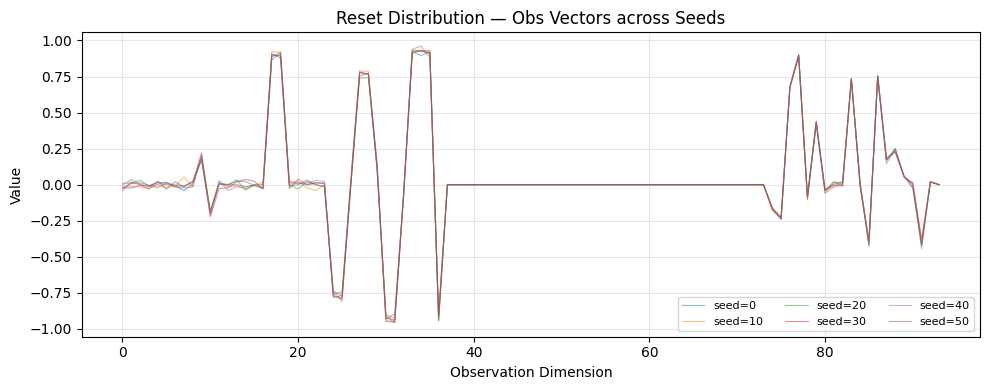

Saved: reset_distribution.png


In [13]:
# Visualise how apple/bowl positions vary across seeds
reset_obs = []
for seed in range(CFG["n_seeds_reset"]):
    o, _ = env.reset(seed=seed * 10)
    reset_obs.append(o.copy())

reset_obs = np.array(reset_obs)
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(min(6, len(reset_obs))):
    ax.plot(reset_obs[i], alpha=0.5, lw=0.8, label=f"seed={i*10}")
ax.set_xlabel("Observation Dimension")
ax.set_ylabel("Value")
ax.set_title("Reset Distribution — Obs Vectors across Seeds")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "reset_distribution.png", dpi=150)
plt.show()
print("Saved: reset_distribution.png")


## Step 6 — Complexity Comparison (Full-Body vs Single-Arm)

Compare the dimensionality of our full-body humanoid task vs a typical
single-arm robot (Panda, 7 DOF — e.g. PickCube).


Could not create PickCube (using defaults): failed to create renderer on device "cuda:0": current SAPIEN version only supports single-GPU rendering.


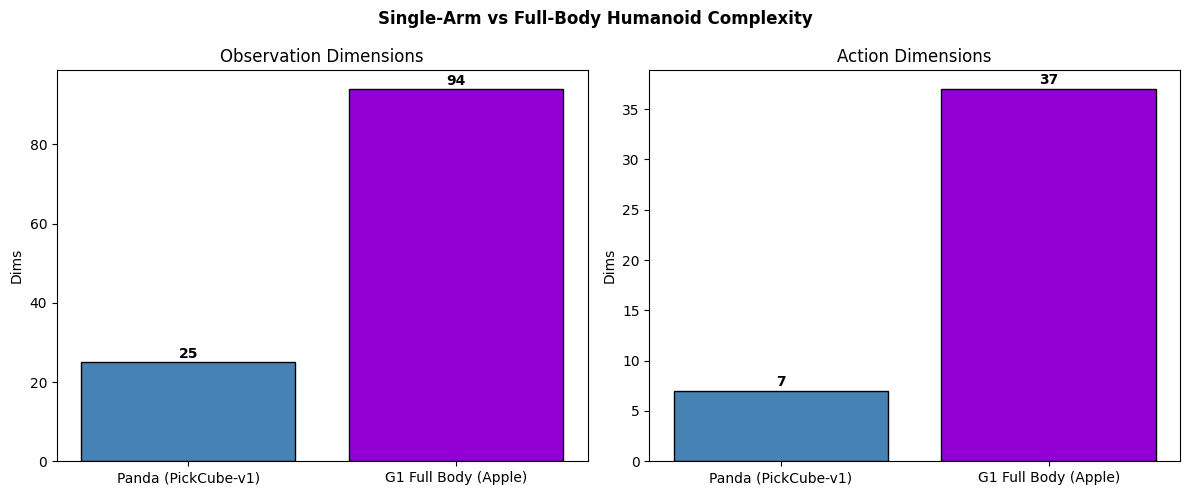

Saved: complexity_comparison.png


In [14]:
try:
    env_panda = gym.make("PickCube-v1", num_envs=1, obs_mode="state",
                         control_mode="pd_joint_delta_pos", render_mode="rgb_array")
    env_panda = CPUGymWrapper(env_panda)
    obs_p, _ = env_panda.reset(seed=0)
    panda_obs = obs_p.shape[0]
    panda_act = env_panda.action_space.shape[0]
    env_panda.close()
except Exception as e:
    print(f"Could not create PickCube (using defaults): {e}")
    panda_obs, panda_act = 25, 7

comparison = {
    "Panda (PickCube-v1)":     {"obs": panda_obs,    "act": panda_act},
    "G1 Full Body (Apple)":    {"obs": obs.shape[0],  "act": env.action_space.shape[0]},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names = list(comparison.keys())
colors = ["steelblue", "darkviolet"]

axes[0].bar(names, [comparison[n]["obs"] for n in names], color=colors, edgecolor="black")
axes[0].set_title("Observation Dimensions")
axes[0].set_ylabel("Dims")
for i, n in enumerate(names):
    axes[0].text(i, comparison[n]["obs"] + 1, str(comparison[n]["obs"]),
                 ha="center", fontweight="bold")

axes[1].bar(names, [comparison[n]["act"] for n in names], color=colors, edgecolor="black")
axes[1].set_title("Action Dimensions")
axes[1].set_ylabel("Dims")
for i, n in enumerate(names):
    axes[1].text(i, comparison[n]["act"] + 0.5, str(comparison[n]["act"]),
                 ha="center", fontweight="bold")

fig.suptitle("Single-Arm vs Full-Body Humanoid Complexity", fontweight="bold")
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "complexity_comparison.png", dpi=150)
plt.show()
print("Saved: complexity_comparison.png")


## Step 7 — Multi-Seed Render Grid


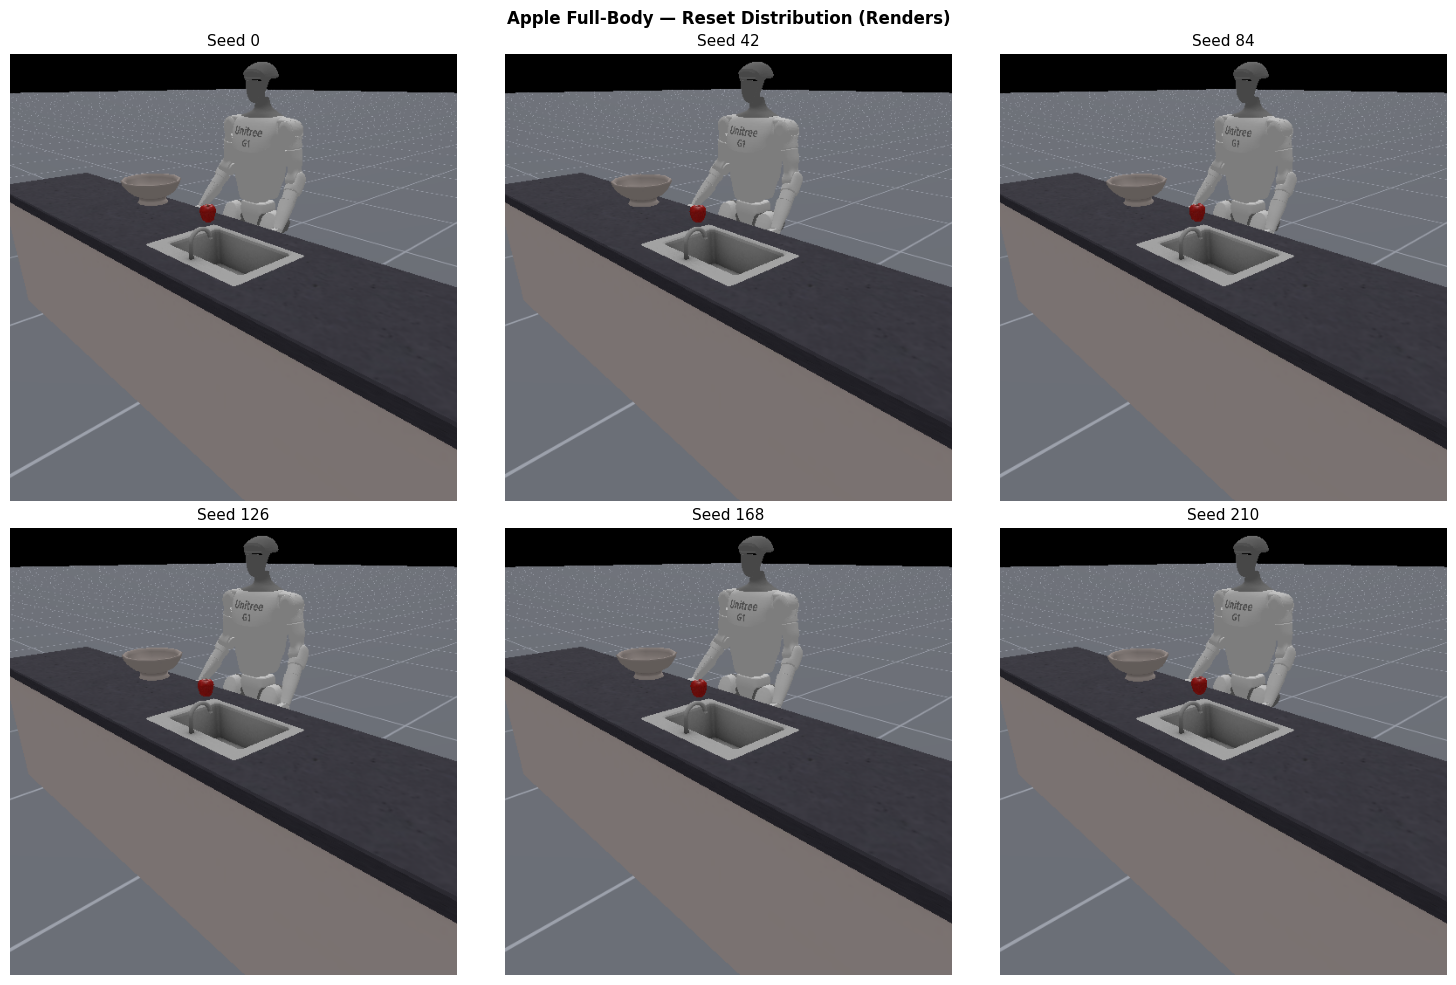

Saved: reset_renders.png


In [16]:
images = []
titles = []
for seed in range(6):
    env.reset(seed=seed * 42)
    try:
        frame = env.render()
        if isinstance(frame, torch.Tensor):
            frame = frame.cpu().numpy()
        if frame.ndim == 4:
            frame = frame[0]
        if frame.dtype in (np.float32, np.float64):
            frame = (frame * 255).clip(0, 255).astype(np.uint8)
        images.append(frame)
        titles.append(f"Seed {seed*42}")
    except Exception:
        pass

if images:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            ax.set_title(titles[i], fontsize=11)
        ax.axis("off")
    fig.suptitle("Apple Full-Body — Reset Distribution (Renders)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(ARTIFACTS_DIR / "reset_renders.png", dpi=150)
    plt.show()
    print("Saved: reset_renders.png")
else:
    print("⚠️ No renders available (CPU-only)")


## Save Artifacts


In [17]:
with open(ARTIFACTS_DIR / "nb02_config.json", "w") as f:
    json.dump(CFG, f, indent=2)

env.close()
print("✅ NB02 Environment Exploration Complete")
print(f"Artifacts saved to: {ARTIFACTS_DIR}")


✅ NB02 Environment Exploration Complete
Artifacts saved to: /root/robotic-sim-dishwash/artifacts/NB02


## References

- ManiSkill 3 documentation: <https://maniskill.readthedocs.io/>
- Unitree G1 URDF: 37 DOF full body (`g1.urdf`)
- Built-in `UnitreeG1PlaceAppleInBowl-v1` (upper body) — our custom env extends to full body
- Custom env: `src/envs/apple_fullbody_env.py`
